<a href="https://colab.research.google.com/github/jvit04/CursoIntroIA/blob/main/Regresion_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#titatic kaggle

In [ ]:
import pandas as pd
datos = pd.read_csv('train.csv')
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Survived', ylabel='count'>

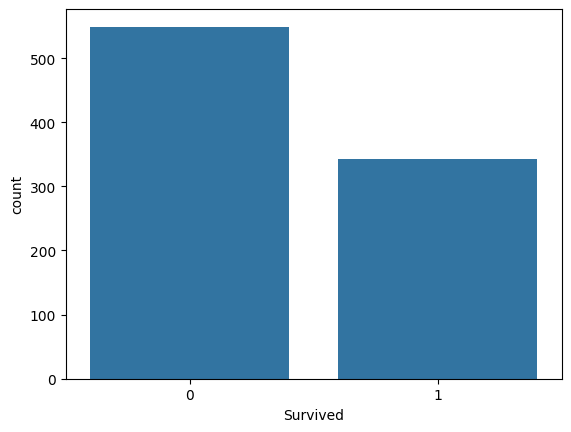

In [ ]:
import seaborn as sb
sb.countplot(x='Survived', data=datos)

<Axes: xlabel='Survived', ylabel='count'>

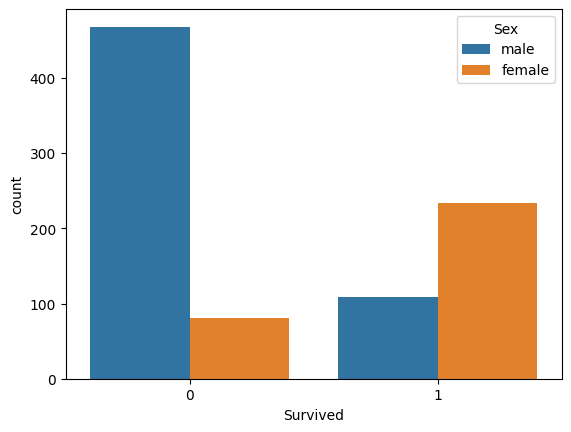

In [ ]:
sb.countplot(x='Survived', data=datos, hue='Sex')

In [ ]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


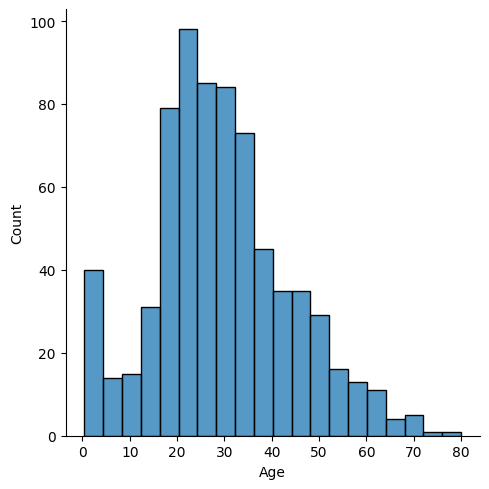

In [ ]:
sb.displot(x='Age', data=datos)

In [ ]:
datos["Age"].mean()

np.float64(29.69911764705882)

In [ ]:
datos["Age"].fillna(datos["Age"].mean(), inplace=True)

In [ ]:
datos["Age"]

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [ ]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
datos = datos.drop('Cabin', axis=1)

In [ ]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
datos = datos.dropna()

In [ ]:
datos = datos.drop(["Name", "PassengerId", "Ticket"],axis=1)

In [ ]:
dummies_sex = pd.get_dummies(datos['Sex'],drop_first=True)
#multicollinearity

In [ ]:
datos = datos.join(dummies_sex)
datos = datos.drop('Sex', axis=1)

In [ ]:
datos.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


<Axes: xlabel='Survived', ylabel='count'>

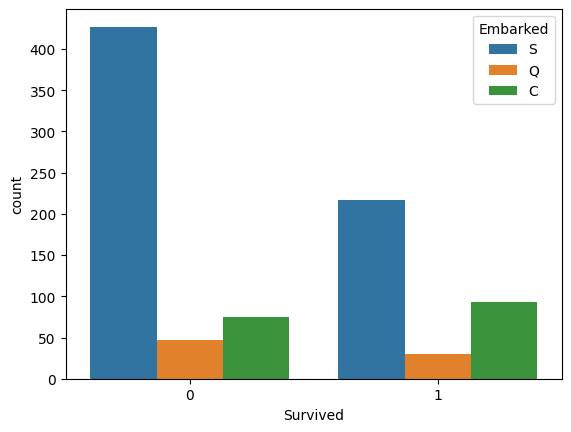

In [ ]:
sb.countplot(x='Survived', data=datos, hue='Embarked')

In [ ]:
dummies_embarked = pd.get_dummies(datos['Embarked'],drop_first=True)

In [ ]:
datos = datos.join(dummies_embarked)
datos = datos.drop('Embarked', axis=1)

<Axes: >

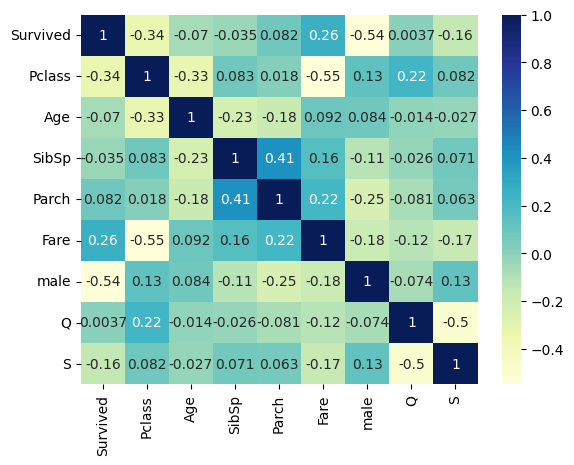

In [ ]:
sb.heatmap(datos.corr(),annot=True, cmap="YlGnBu")

<Axes: xlabel='Survived', ylabel='count'>

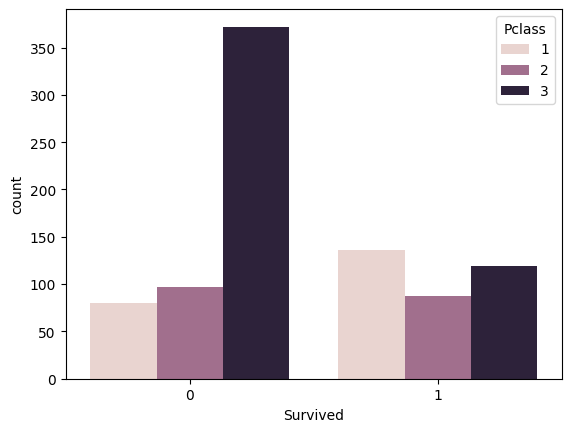

In [ ]:
sb.countplot(x="Survived", data=datos, hue="Pclass")

In [ ]:
x = datos.drop("Survived", axis=1)
y = datos["Survived"]

In [ ]:
from sklearn.model_selection import train_test_split

x_ent, x_pru, y_ent, y_pru = train_test_split(x,y,test_size=.2)

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(x_ent, y_ent)

LogisticRegression(max_iter=1000)

In [ ]:
predicciones = modelo.predict(x_pru)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_pru, predicciones)

0.770949720670391

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82       111
           1       0.73      0.63      0.68        68

    accuracy                           0.77       179
   macro avg       0.76      0.74      0.75       179
weighted avg       0.77      0.77      0.77       179



In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_pru, predicciones)

array([[95, 16],
       [25, 43]])

In [ ]:
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["Pred: No", "Pred: Si"], index=["Real: No", "Real: Si"])

,Pred: No,Pred: Si
Real: No,95,16
Real: Si,25,43


In [ ]:
x.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [ ]:
import pandas as pd

# The original list representing a single new person
# Values correspond to Pclass, Age, SibSp, Parch, Fare, male, Q, S
nueva_persona_list = [3, 35, 0, 0, 10, 1, 0, 0]

# Get the column names from the training data 'x' to ensure consistency
feature_names = x.columns.tolist()

# Create a DataFrame with the new person's data
# Wrap the list in another list to make it a 2D structure (one row, multiple columns)
nueva_persona_df = pd.DataFrame([nueva_persona_list], columns=feature_names)

# Convert the relevant columns to boolean type, as they were in the training data 'x'
# Assuming 'male', 'Q', 'S' are the boolean columns based on prior processing
if 'male' in nueva_persona_df.columns:
    nueva_persona_df['male'] = nueva_persona_df['male'].astype(bool)
if 'Q' in nueva_persona_df.columns:
    nueva_persona_df['Q'] = nueva_persona_df['Q'].astype(bool)
if 'S' in nueva_persona_df.columns:
    nueva_persona_df['S'] = nueva_persona_df['S'].astype(bool)

prediccion = modelo.predict(nueva_persona_df)
if prediccion[0] == 0:
    print("No sobrevivió")
else:
    print("Sobrevivió")

No sobrevivió
